# Almgren-Chriss Optimal Execution

**Docker image**: `ml4t`

This notebook implements the Almgren-Chriss (2001) framework for optimal trade
execution: closed-form trajectories, the efficient frontier of execution
strategies, and a Transaction Cost Analysis (TCA) demonstration.

**Learning Objectives**
- Understand the market impact vs timing risk trade-off
- Implement the Almgren-Chriss closed-form solution for optimal trajectories
- Compute the efficient frontier of execution strategies
- Perform Monte Carlo simulation and produce a basic TCA report

**Book Reference:** Chapter 18, Section 18.6 (Optimizing Execution with
Almgren-Chriss as a Unifying Framework)

**Prerequisites:** Read [`04_vwap_twap_execution`](04_vwap_twap_execution.ipynb)
for benchmark schedules and
[`03_market_impact_calibration`](03_market_impact_calibration.ipynb) for the
empirical interpretation of the impact inputs.

## The Optimal Execution Problem

When liquidating a position, we face two competing costs:

1. **Market Impact**: Trading fast moves prices against us
2. **Timing Risk**: Trading slow exposes us to price volatility

The Almgren-Chriss model finds the **optimal trade-off** between these costs.

## Imports & Settings

In [1]:
"""Almgren-Chriss Optimal Execution - Efficient frontier, optimal trajectories, and TCA."""

from dataclasses import dataclass
from datetime import datetime, timedelta

import numpy as np
import plotly.graph_objects as go
import polars as pl

from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_palette

In [2]:
N_RISK_AVERSIONS = 100  # Points along the efficient frontier (risk-aversion sweep)
SEED = 42
N_SIMULATIONS = 1000
TRAJECTORY_RISK_AVERSIONS = [0.0, 1e-13, 1e-12, 1e-11, 1e-10]
FRONTIER_LOG10_RANGE = (-14, -6)
SIMULATION_RISK_AVERSIONS = [0.0, 1e-11, 1e-9]

In [3]:
set_global_seeds(SEED)

## Part 1: Model Setup

### Price Dynamics

For a sell program, the unaffected price evolves as:
$$S_k = S_{k-1} - \gamma n_k + \sigma_P \tau^{1/2} \xi_k$$

where:
- $S_k$ = price after period $k$
- $\sigma_P = S_0\sigma/\sqrt{252}$ = daily price volatility in USD
- $\tau$ = time step
- $\xi_k \sim N(0,1)$ = random shock
- $\gamma n_k$ = permanent price impact of selling $n_k$ shares

### Impact Functions

**Permanent Impact** (information):
$$g(n) = \gamma n$$

**Temporary Impact** (liquidity):
$$h(n) = \epsilon \, \text{sign}(n) + \eta \frac{n}{\tau}$$

The simulated sell price subtracts spread and temporary impact. It also charges
half of the current child order's permanent impact, a convention that makes the
zero-shock simulation reconcile exactly with the expected-cost functional below.

In [4]:
@dataclass
class AlmgrenChrissParams:
    """Parameters for Almgren-Chriss model."""

    X: int = 100_000  # Shares to liquidate
    T: float = 1.0  # Trading horizon in days
    N: int = 10  # Trading periods
    S0: float = 100.0  # Arrival price in USD
    sigma: float = 0.30  # Annual return volatility
    gamma: float = 0.05  # Permanent-impact bps at 100% ADV
    eta: float = 0.10  # Temporary-impact bps at 100% interval participation
    epsilon: float = 5.0  # Half-spread in bps
    ADV: float = 1_000_000  # Average daily shares

    def __post_init__(self) -> None:
        """Validate inputs and convert impact coefficients to price units."""
        positive = {"X": self.X, "T": self.T, "N": self.N, "S0": self.S0, "ADV": self.ADV}
        if any(value <= 0 for value in positive.values()):
            raise ValueError("Position, horizon, periods, price, and ADV must be positive")
        if self.eta <= 0:
            raise ValueError("Temporary-impact coefficient eta must be positive")
        if any(value < 0 for value in (self.sigma, self.gamma, self.epsilon)):
            raise ValueError("Volatility and remaining cost inputs must be nonnegative")
        self.gamma_price = self.gamma * self.S0 / (self.ADV * 10_000)
        self.eta_price = self.eta * self.S0 / (self.ADV * 10_000)
        self.epsilon_price = self.epsilon * self.S0 / 10_000

    @property
    def tau(self) -> float:
        """Time step."""
        return self.T / self.N

    @property
    def sigma_daily(self) -> float:
        """Daily return volatility."""
        return self.sigma / np.sqrt(252)

    @property
    def sigma_price_daily(self) -> float:
        """Daily price volatility in USD per share."""
        return self.S0 * self.sigma_daily

In [5]:
params = AlmgrenChrissParams(
    X=100_000,
    T=5.0,  # 5 days
    N=50,  # 50 periods
    S0=100.0,
    sigma=0.30,
    gamma=0.05,
    eta=0.10,
    epsilon=5.0,
    ADV=1_000_000,
)

print("Almgren-Chriss Parameters")
print(f"Position:          {params.X:,} shares (${params.X * params.S0 / 1e6:.1f}M)")
print(f"Horizon:           {params.T} days ({params.N} periods)")
print(f"ADV:               {params.ADV:,} shares")
print(f"Participation:     {params.X / (params.ADV * params.T):.1%} of volume")
print(f"Daily Volatility:  {params.sigma_daily:.2%} (${params.sigma_price_daily:.2f}/share)")
print(f"Permanent γ:       {params.gamma} bps at 100% ADV")
print(f"Temporary η:       {params.eta} bps at 100% interval participation")

Almgren-Chriss Parameters
Position:          100,000 shares ($10.0M)
Horizon:           5.0 days (50 periods)
ADV:               1,000,000 shares
Participation:     2.0% of volume
Daily Volatility:  1.89% ($1.89/share)
Permanent γ:       0.05 bps at 100% ADV
Temporary η:       0.1 bps at 100% interval participation


**Finding**: These parameters define the whole execution problem. Once position
size, horizon, liquidity, and volatility are fixed, the notebook is solving for
the least painful way to trade, not whether the trade itself is profitable.

## Part 2: Execution Cost and Risk

### Expected Cost (Implementation Shortfall)

$$E[C] = \frac{1}{2} \gamma X^2 + \epsilon X + \eta \sum_{k=1}^{N} \frac{n_k^2}{\tau}$$

where $n_k$ is shares traded in period $k$.

### Execution Risk (Variance)

$$V[C] = \sigma_P^2 \sum_{k=1}^{N} \tau \, x_k^2$$

where $x_k$ is the post-trade position exposed to the next price shock.

In [6]:
def compute_trajectory_from_list(trade_list: np.ndarray, X: int) -> np.ndarray:
    """Convert trade list to position trajectory."""
    trade_list = np.asarray(trade_list, dtype=float)
    if trade_list.ndim != 1 or not np.isfinite(trade_list).all():
        raise ValueError("trade_list must be a finite one-dimensional array")
    if (trade_list < 0).any() or not np.isclose(trade_list.sum(), X):
        raise ValueError("A liquidation schedule must be nonnegative and sum to X")
    trajectory = np.zeros(len(trade_list) + 1)
    trajectory[0] = X
    for k, n in enumerate(trade_list):
        trajectory[k + 1] = trajectory[k] - n
    return trajectory

#### Expected Cost Functional

In [7]:
def expected_cost(
    trade_list: np.ndarray,
    params: AlmgrenChrissParams,
) -> float:
    """Compute expected cost (implementation shortfall)."""
    trade_list = np.asarray(trade_list, dtype=float)
    compute_trajectory_from_list(trade_list, params.X)
    X = params.X
    tau = params.tau
    gamma = params.gamma_price
    eta = params.eta_price
    epsilon = params.epsilon_price

    perm_cost = 0.5 * gamma * X**2
    fixed_cost = epsilon * abs(X)
    temp_cost = eta * np.sum(trade_list**2) / tau

    return perm_cost + fixed_cost + temp_cost

#### Execution Variance Functional

In [8]:
def execution_variance(
    trade_list: np.ndarray,
    params: AlmgrenChrissParams,
) -> float:
    """Compute execution variance (timing risk)."""
    trajectory = compute_trajectory_from_list(trade_list, params.X)
    sigma = params.sigma_price_daily
    tau = params.tau

    # Each shock occurs after that period's trade, so it reaches post-trade inventory.
    return sigma**2 * tau * np.sum(trajectory[1:] ** 2)

#### Execution Standard Deviation Helper

In [9]:
def execution_std(trade_list: np.ndarray, params: AlmgrenChrissParams) -> float:
    """Compute execution standard deviation."""
    return np.sqrt(execution_variance(trade_list, params))

In [10]:
twap_trades = np.full(params.N, params.X / params.N)

aggressive_trades = np.zeros(params.N)
aggressive_trades[0] = params.X  # All in first period

gradual_trades = np.zeros(params.N)
gradual_trades[:5] = params.X / 5  # First 5 periods

strategies = {
    "TWAP": twap_trades,
    "Aggressive": aggressive_trades,
    "Front-loaded": gradual_trades,
}

strategy_comparison = pl.DataFrame(
    [
        {
            "strategy": name,
            "expected_cost_usd": expected_cost(trades, params),
            "cost_std_usd": execution_std(trades, params),
        }
        for name, trades in strategies.items()
    ]
)
strategy_comparison

strategy,expected_cost_usd,cost_std_usd
str,f64,f64
"""TWAP""",5004.5,240312.296814
"""Aggressive""",5102.5,0.0
"""Front-loaded""",5022.5,65465.367071


**Finding**: The strategy table makes the mean-variance trade-off tangible before
any optimization occurs. TWAP is not optimal by definition; it is simply one
point in the cost-risk space.

## Part 3: Optimal Trajectory

### Mean-Variance Optimization

The trader minimizes:
$$\min_{n_1, ..., n_N} E[C] + \lambda V[C]$$

where $\lambda$ is the risk aversion parameter.

### Exact Finite-Period Solution

For the discrete objective used here, define:
$$\theta = \frac{\lambda \sigma_P^2 \tau^2}{\eta}, \qquad
\alpha = \operatorname{arccosh}\left(1 + \frac{\theta}{2}\right)
= 2\operatorname{asinh}\left(\frac{\sqrt{\theta}}{2}\right).$$

The exact inventory path over $N$ periods is:
$$x_k = X \frac{\sinh\left(\alpha(N-k)\right)}{\sinh(\alpha N)}.$$

The familiar continuous-time parameter is the small-step approximation
$\kappa = \alpha/\tau \approx \sqrt{\lambda\sigma_P^2/\eta}$. Using that
approximation directly can misstate the optimum when $\theta$ is not small.
The numerical scale of $\lambda$ still depends on the dollar units of
$\sigma_P$ and $\eta$, so the sweep is reported rather than treated as a
universal calibration.

In [11]:
def optimal_trajectory(
    params: AlmgrenChrissParams,
    risk_aversion: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute the exact finite-period Almgren-Chriss trajectory.

    Parameters
    ----------
    params : AlmgrenChrissParams
    risk_aversion : float
        Risk aversion parameter λ (higher = more aggressive)

    Returns
    -------
    times : array
        Time points
    trajectory : array
        Optimal position at each time
    """
    X = params.X
    T = params.T
    N = params.N
    tau = params.tau
    sigma = params.sigma_price_daily
    eta = params.eta_price

    if risk_aversion < 0:
        raise ValueError("risk_aversion must be nonnegative")
    times = np.linspace(0, T, N + 1)
    theta = risk_aversion * sigma**2 * tau**2 / eta
    if theta == 0:
        trajectory = X * (1 - times / T)
    else:
        alpha = 2 * np.arcsinh(np.sqrt(theta) / 2)
        periods_remaining = np.arange(N, -1, -1, dtype=float)
        scaled_remaining = alpha * periods_remaining
        scaled_horizon = alpha * N
        numerator = np.exp(scaled_remaining - scaled_horizon) * -np.expm1(-2 * scaled_remaining)
        denominator = -np.expm1(-2 * scaled_horizon)
        trajectory = X * numerator / denominator
    trajectory[-1] = 0.0

    return times, trajectory

#### Convert Trajectory to Trade List

In [12]:
def trajectory_to_trades(trajectory: np.ndarray) -> np.ndarray:
    """Convert position trajectory to trade list."""
    return -np.diff(trajectory)

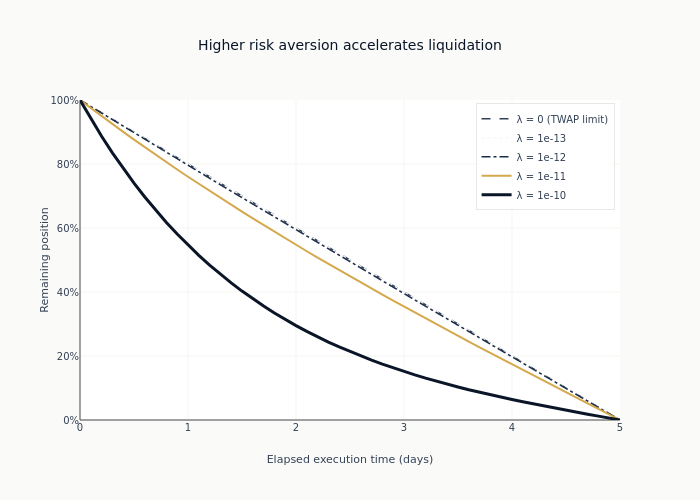

In [13]:
fig = go.Figure()
trajectory_styles = [
    dict(color=COLORS["neutral"], dash="dash", width=1.5),
    dict(color=COLORS["silver"], dash="dot", width=1.5),
    dict(color=COLORS["slate"], dash="dashdot", width=1.5),
    dict(color=COLORS["amber"], dash="solid", width=2),
    dict(color=COLORS["blue"], dash="solid", width=3),
]

for line_style, lambda_ in zip(trajectory_styles, TRAJECTORY_RISK_AVERSIONS):
    times, traj = optimal_trajectory(params, lambda_)
    _ = fig.add_scatter(
        x=times,
        y=traj / params.X,
        mode="lines",
        name=f"λ = {lambda_:.0e}" if lambda_ else "λ = 0 (TWAP limit)",
        line=line_style,
    )

fig.update_layout(
    title="Higher risk aversion accelerates liquidation",
    xaxis_title="Elapsed execution time (days)",
    yaxis_title="Remaining position",
    yaxis_tickformat=".0%",
    yaxis_range=[0, 1],
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99),
)
fig.show()

**Finding**: As risk aversion rises, the trajectory bends forward and empties the
book faster. In Almgren-Chriss, urgency is not a story the trader tells; it is a
parameter that literally reshapes the schedule.

## Part 4: Efficient Frontier of Execution

For each level of expected cost, there's a minimum variance trajectory.
The locus of these points forms the **efficient frontier**.

In [14]:
def compute_efficient_frontier(
    params: AlmgrenChrissParams,
    n_points: int = 50,
) -> pl.DataFrame:
    """Compute the efficient frontier of execution strategies."""
    lambdas = np.logspace(*FRONTIER_LOG10_RANGE, n_points)

    results = []
    for lambda_ in lambdas:
        _, traj = optimal_trajectory(params, lambda_)
        trades = trajectory_to_trades(traj)

        cost = expected_cost(trades, params)
        risk = execution_std(trades, params)

        results.append(
            {
                "lambda": lambda_,
                "expected_cost": cost,
                "cost_bps": cost / (params.X * params.S0) * 10000,
                "risk_std": risk,
                "risk_bps": risk / (params.X * params.S0) * 10000,
            }
        )

    return pl.DataFrame(results)

In [15]:
frontier = compute_efficient_frontier(params, n_points=N_RISK_AVERSIONS)

strategies_to_mark = [
    (1e-13, "Low risk aversion (λ=1e-13)"),
    (1e-11, "Moderate risk aversion (λ=1e-11)"),
    (1e-9, "High risk aversion (λ=1e-9)"),
]

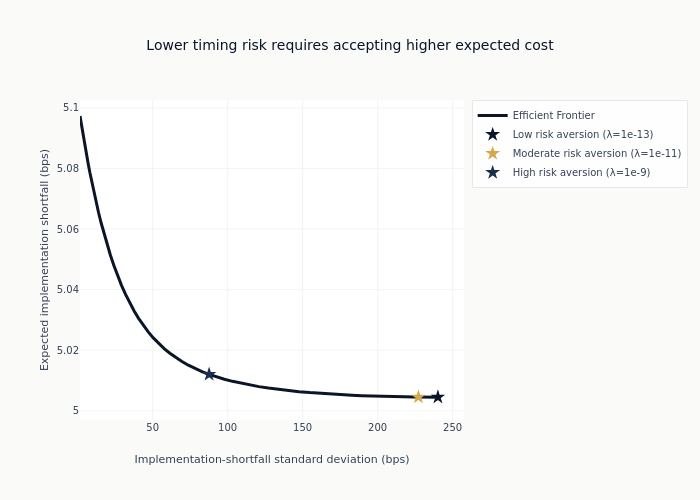

In [16]:
fig = go.Figure()
frontier_for_plot = frontier.sort("risk_bps")
_ = fig.add_scatter(
    x=frontier_for_plot["risk_bps"].to_list(),
    y=frontier_for_plot["cost_bps"].to_list(),
    mode="lines",
    name="Efficient Frontier",
    line=dict(color=COLORS["blue"], width=3),
)
for color, (lambda_, name) in zip(ml4t_palette(3, categorical=True), strategies_to_mark):
    row = (
        frontier.with_columns(distance=(pl.col("lambda").log10() - np.log10(lambda_)).abs())
        .sort("distance")
        .row(0, named=True)
    )
    _ = fig.add_scatter(
        x=[row["risk_bps"]],
        y=[row["cost_bps"]],
        mode="markers",
        marker=dict(size=11, symbol="star", color=color),
        name=name,
    )
fig.update_layout(
    title="Lower timing risk requires accepting higher expected cost",
    xaxis_title="Implementation-shortfall standard deviation (bps)",
    yaxis_title="Expected implementation shortfall (bps)",
    height=500,
)
fig.show()

In [17]:
print("Frontier Statistics:")
print(
    f"  Min Cost: {frontier['cost_bps'].min():.3f} bps "
    f"(at {frontier['risk_bps'].max():.1f} bps risk)"
)
print(
    f"  Min Risk: {frontier['risk_bps'].min():.1f} bps "
    f"(at {frontier['cost_bps'].max():.3f} bps cost)"
)

Frontier Statistics:
  Min Cost: 5.005 bps (at 240.3 bps risk)
  Min Risk: 1.6 bps (at 5.097 bps cost)


**Finding**: The frontier makes the optimization problem explicit. There is no
single best trajectory; each point is a different compromise between paying
impact now and bearing price uncertainty over the rest of the schedule.

## Part 5: Simulation and TCA

Paired synthetic price paths separate timing-risk dispersion from expected impact.

In [18]:
def simulate_single_execution(
    params: AlmgrenChrissParams,
    trade_list: np.ndarray,
    shocks: np.ndarray,
) -> dict:
    """Simulate one execution path under Almgren-Chriss price dynamics.

    `shocks` is a pre-generated array of standard-normal draws (one per period)
    so that different strategies can be evaluated against the *same* price path
    for a given simulation index - a paired Monte Carlo design that removes
    sampling noise from the strategy comparison.
    """
    trade_list = np.asarray(trade_list, dtype=float)
    shocks = np.asarray(shocks, dtype=float)
    compute_trajectory_from_list(trade_list, params.X)
    if shocks.shape != trade_list.shape or not np.isfinite(shocks).all():
        raise ValueError("shocks must be finite with one value per trade")
    tau = params.tau
    sigma = params.sigma_price_daily
    gamma = params.gamma_price
    eta = params.eta_price
    epsilon = params.epsilon_price
    price = params.S0
    total_proceeds = 0.0
    prices = [price]

    for k, n_k in enumerate(trade_list):
        exec_price = price - 0.5 * gamma * n_k - epsilon - eta * n_k / tau
        total_proceeds += exec_price * n_k
        price = price - gamma * n_k
        price = price + sigma * np.sqrt(tau) * shocks[k]
        prices.append(price)

    avg_exec_price = total_proceeds / params.X
    is_dollar = params.S0 * params.X - total_proceeds
    is_bps = is_dollar / (params.S0 * params.X) * 10000
    return {
        "avg_exec_price": avg_exec_price,
        "final_price": prices[-1],
        "is_dollar": is_dollar,
        "is_bps": is_bps,
        "total_proceeds": total_proceeds,
    }

### Monte Carlo Wrapper for Execution Paths

In [19]:
def simulate_execution(
    params: AlmgrenChrissParams,
    trade_list: np.ndarray,
    n_simulations: int = 1000,
    seed: int = SEED,
) -> pl.DataFrame:
    """
    Simulate execution with price dynamics.

    Simulation indices share paths across strategies. Consecutive indices use
    antithetic shocks from ``np.random.default_rng(seed + sim // 2)`` so an even
    run count centers each strategy on its analytical expected cost.

    Returns
    -------
    DataFrame with simulation results
    """
    if n_simulations <= 0 or n_simulations % 2:
        raise ValueError("n_simulations must be a positive even integer")
    results = []

    for sim in range(n_simulations):
        pair_index = sim // 2
        rng = np.random.default_rng(seed + pair_index)
        shocks = rng.standard_normal(len(trade_list))
        if sim % 2:
            shocks = -shocks
        result = simulate_single_execution(params, trade_list, shocks)
        result["simulation"] = sim
        results.append(result)

    return pl.DataFrame(results)

In [20]:
simulation_results = {}

simulation_labels = [
    "Risk-neutral (λ=0, TWAP)",
    "Balanced (λ=1e-11)",
    "Risk-averse (λ=1e-9)",
]
for name, risk_aversion in zip(simulation_labels, SIMULATION_RISK_AVERSIONS):
    _, traj = optimal_trajectory(params, risk_aversion)
    trades = trajectory_to_trades(traj)
    sim_df = simulate_execution(params, trades, n_simulations=N_SIMULATIONS)
    simulation_results[name] = sim_df

#### TCA Summary Statistics

In [21]:
tca_summary = pl.DataFrame(
    [
        {
            "strategy": name,
            "is_mean_bps": df["is_bps"].mean(),
            "is_std_bps": df["is_bps"].std(),
            "is_p5_bps": df["is_bps"].quantile(0.05),
            "is_p95_bps": df["is_bps"].quantile(0.95),
        }
        for name, df in simulation_results.items()
    ]
)
tca_summary

strategy,is_mean_bps,is_std_bps,is_p5_bps,is_p95_bps
str,f64,f64,f64,f64
"""Risk-neutral (λ=0, TWAP)""",5.0045,241.263258,-401.72943,411.73843
"""Balanced (λ=1e-11)""",5.00453,227.514016,-379.643838,389.652898
"""Risk-averse (λ=1e-9)""",5.011907,87.926656,-147.825751,157.849566


**Finding**: The TCA summary reports both the center and tails of each paired
synthetic shortfall distribution. The 5th and 95th percentiles show how much
timing exposure remains after the schedule is fixed.

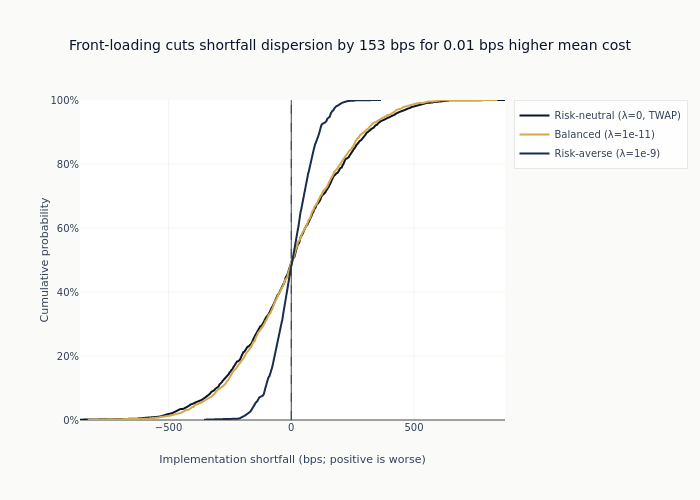

In [22]:
fig = go.Figure()
distribution_colors = ml4t_palette(len(simulation_results), categorical=True)
for color, (name, df) in zip(distribution_colors, simulation_results.items()):
    shortfall = np.sort(df["is_bps"].to_numpy())
    cumulative_probability = np.arange(1, len(shortfall) + 1) / len(shortfall)
    _ = fig.add_scatter(
        x=shortfall,
        y=cumulative_probability,
        mode="lines",
        name=name,
        line=dict(color=color, width=2),
    )
risk_neutral_row = tca_summary.row(0, named=True)
risk_averse_row = tca_summary.row(-1, named=True)
dispersion_reduction = risk_neutral_row["is_std_bps"] - risk_averse_row["is_std_bps"]
mean_cost_increase = risk_averse_row["is_mean_bps"] - risk_neutral_row["is_mean_bps"]
fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title=(
        f"Front-loading cuts shortfall dispersion by {dispersion_reduction:.0f} bps "
        f"for {mean_cost_increase:.2f} bps higher mean cost"
    ),
    xaxis_title="Implementation shortfall (bps; positive is worse)",
    yaxis_title="Cumulative probability",
    yaxis_tickformat=".0%",
    yaxis_range=[0, 1],
    height=500,
)
fig.show()

**Finding**: The empirical distribution makes the price of urgency visible.
Front-loading narrows timing-driven dispersion because less inventory remains
exposed to shocks, while its higher participation raises expected impact cost.

## Part 6: Practical Extensions

### Extensions to Basic Model

1. **Non-linear impact**: Replace $h(n) = \eta n$ with $h(n) = \eta |n|^{1/2}$
2. **Time-varying liquidity**: $\eta(t)$ varies intraday
3. **Stochastic volatility**: $\sigma(t)$ varies with regime
4. **Urgency**: Trader may have alpha that decays

#### Non-Linear Impact Extension

In [23]:
@dataclass
class ExtendedParams(AlmgrenChrissParams):
    """Extended parameters with non-linear impact."""

    impact_exponent: float = 0.5

    def __post_init__(self) -> None:
        super().__post_init__()
        if not 0 < self.impact_exponent <= 1:
            raise ValueError("impact_exponent must lie in (0, 1]")

#### Non-Linear Cost Functional

In [24]:
def expected_cost_nonlinear(
    trade_list: np.ndarray,
    params: ExtendedParams,
) -> float:
    """Expected cost with square-root temporary impact."""
    trade_list = np.asarray(trade_list, dtype=float)
    compute_trajectory_from_list(trade_list, params.X)
    X = params.X
    tau = params.tau
    gamma = params.gamma_price
    epsilon = params.epsilon_price
    alpha = params.impact_exponent

    perm_cost = 0.5 * gamma * X**2
    fixed_cost = epsilon * abs(X)
    interval_market_volume = params.ADV * tau
    participation = trade_list / interval_market_volume
    temp_cost = (
        params.S0 / 10_000 * params.eta * np.sum(trade_list * np.power(participation, alpha))
    )

    return perm_cost + fixed_cost + temp_cost

In [25]:
extended_params = ExtendedParams(
    X=100_000,
    T=5.0,
    N=50,
    S0=100.0,
    sigma=0.30,
    gamma=0.05,
    eta=0.10,
    epsilon=5.0,
    ADV=1_000_000,
    impact_exponent=0.5,
)

twap_trades = np.full(extended_params.N, extended_params.X / extended_params.N)

linear_cost = expected_cost(twap_trades, params)
nonlinear_cost = expected_cost_nonlinear(twap_trades, extended_params)

print("Impact Model Comparison (TWAP)")
print(f"Linear Impact:     ${linear_cost:,.0f}")
print(f"Square-Root Impact: ${nonlinear_cost:,.0f}")
print(f"Difference:        {(nonlinear_cost / linear_cost - 1) * 100:+.1f}%")

Impact Model Comparison (TWAP)
Linear Impact:     $5,004
Square-Root Impact: $5,017
Difference:        +0.2%


**Finding**: The square-root specification maps each child order to its share of
interval volume before applying the exponent. This normalization keeps the
coefficient in bps and shows why model choice matters even for the same schedule.

## Part 7: Transaction Cost Analysis (TCA) Dashboard

A comprehensive TCA report includes:
1. **Cost breakdown**: Spread, impact, and timing when counterfactuals identify them
2. **Benchmark comparison**: vs VWAP, arrival, close
3. **Attribution**: By time, size, urgency

In [26]:
def generate_tca_report(
    executed_trades: pl.DataFrame,
    benchmark_prices: dict,
    params: AlmgrenChrissParams,
) -> dict:
    """
    Generate TCA report.

    Parameters
    ----------
    executed_trades : DataFrame
        Columns: timestamp, shares, exec_price
    benchmark_prices : dict
        arrival, vwap, close prices
    params : Model parameters

    Returns
    -------
    dict : TCA metrics
    """
    required = {"timestamp", "shares", "exec_price"}
    if not required.issubset(executed_trades.columns):
        raise ValueError(f"executed_trades must contain {sorted(required)}")
    if (executed_trades["shares"] <= 0).any() or (executed_trades["exec_price"] <= 0).any():
        raise ValueError("shares and execution prices must be positive")
    total_shares = executed_trades["shares"].sum()
    total_cost = (executed_trades["shares"] * executed_trades["exec_price"]).sum()
    avg_price = total_cost / total_shares

    arrival = benchmark_prices["arrival"]
    vwap = benchmark_prices["vwap"]
    close = benchmark_prices["close"]
    if min(arrival, vwap, close) <= 0:
        raise ValueError("benchmark prices must be positive")

    return {
        "total_shares": total_shares,
        "total_value": total_cost,
        "avg_exec_price": avg_price,
        "vs_arrival_bps": (arrival - avg_price) / arrival * 10000,
        "vs_vwap_bps": (vwap - avg_price) / vwap * 10000,
        "vs_close_bps": (close - avg_price) / close * 10000,
        "assumed_half_spread_bps": params.epsilon,
    }

In [27]:
example_trades = pl.DataFrame(
    {
        "timestamp": [datetime(2024, 1, 15, 9, 30) + timedelta(minutes=15 * i) for i in range(10)],
        "shares": [10000] * 10,
        "exec_price": [
            100.02,
            100.05,
            100.08,
            100.06,
            100.09,
            100.12,
            100.10,
            100.08,
            100.11,
            100.15,
        ],
    }
)

In [28]:
benchmarks = {
    "arrival": 100.00,
    "vwap": 100.08,
    "close": 100.12,
}

tca = generate_tca_report(example_trades, benchmarks, params)

In [29]:
tca_report = pl.DataFrame(
    [
        {"metric": "Total shares", "value": f"{tca['total_shares']:,}"},
        {"metric": "Total value ($)", "value": f"{tca['total_value']:,.0f}"},
        {"metric": "Avg execution price ($)", "value": f"{tca['avg_exec_price']:.4f}"},
        {"metric": "vs Arrival (bps)", "value": f"{tca['vs_arrival_bps']:+.1f}"},
        {"metric": "vs VWAP (bps)", "value": f"{tca['vs_vwap_bps']:+.1f}"},
        {"metric": "vs Close (bps)", "value": f"{tca['vs_close_bps']:+.1f}"},
        {
            "metric": "Assumed half-spread (bps)",
            "value": f"{tca['assumed_half_spread_bps']:.1f}",
        },
    ]
)
tca_report

metric,value
str,str
"""Total shares""","""100,000"""
"""Total value ($)""","""10,008,600"""
"""Avg execution price ($)""","""100.0860"""
"""vs Arrival (bps)""","""-8.6"""
"""vs VWAP (bps)""","""-0.6"""
"""vs Close (bps)""","""+3.4"""
"""Assumed half-spread (bps)""","""5.0"""


**Interpretation**: TCA closes the loop between model and implementation. Benchmark
slippage is observable here, but impact and timing are not separately identified
without a counterfactual price or impact model. The assumed spread is therefore
reported as an input rather than presented as an empirical decomposition.

## Summary

### Almgren-Chriss Framework

1. **The Trade-off**: Market impact vs timing risk
2. **Optimal Solution**: Closed-form trajectory based on risk aversion λ
3. **Efficient Frontier**: Minimum risk for each cost level

### Key Parameters

| Parameter | Meaning | Effect |
|-----------|---------|--------|
| λ | Risk aversion | Higher = more aggressive |
| γ | Permanent impact | Information content of trade |
| η | Temporary impact | Liquidity consumption |
| σ | Volatility | Timing risk |

### Practical Guidelines

1. **Estimate parameters** from historical execution data
2. **Choose λ** based on urgency (alpha decay)
3. **Monitor execution** and adjust for market conditions
4. **Use TCA** to improve future executions without claiming unidentifiable attribution

### Extensions

- Non-linear impact (square-root)
- Time-varying parameters
- Multi-asset execution
- Reinforcement learning approaches

## Key Takeaways

1. **Efficient frontier**: The demo's fixed half-spread dominates expected cost,
   while dollar timing risk falls as the schedule front-loads. The frontier's
   shape, not this stylized calibration's absolute scale, is the teaching result.
2. **Risk aversion controls position on the frontier**: low $\lambda$ produces
   TWAP-like flat schedules; high $\lambda$ front-loads execution and accepts
   more impact for less variance.
3. **Paired simulation clarifies urgency**: front-loading reduces dispersion by
   leaving less inventory exposed to shocks, at the cost premium reported in
   the executed TCA table and distribution title.
4. **Impact units matter**: the square-root extension normalizes each child order
   by interval market volume before applying its exponent. A linear coefficient
   cannot be reused under a different exponent without preserving those units.
5. **TCA needs counterfactuals**: benchmark slippage is observable, but impact
   and timing attribution require an explicit model or unaffected-price estimate.
   Optimal execution is therefore an auditable cost-risk trade-off, not a claim
   that scheduling removes costs.

**Next**: `08_ml_dynamic_execution` extends this with ML-based adaptive execution.
**Book**: Section 18.6 discusses the Almgren-Chriss framework in depth.